In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from src.Net import Net
from src.MyDataset import MyDataset


import time

c:\Users\user\anaconda3\envs\imageClassification\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

In [3]:
#  CONSTANTS
batch_size = 32
num_workers = 4

epochs = 80
mini_batches_len = 10

In [ ]:
train_set = MyDataset("./labels/train_labels.csv", "./imgs/dataset/train_imgs", transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)

print(f"Train set length: {len(train_set)}")

Train set length: 2499


In [5]:
classes = ("apple", "banana", "orange", "pineapple", "watermelon")

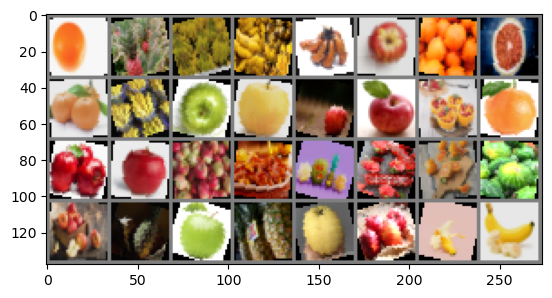

orange pineapple banana banana banana apple orange orange orange banana apple apple apple apple orange orange apple apple apple pineapple pineapple watermelon orange watermelon apple pineapple apple pineapple apple apple banana banana


In [6]:

def imshow(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

print(' '.join('%s' % classes[labels[j]] for j in range(batch_size)))

In [7]:
net = Net()
print(net)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


In [8]:
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)
# optimizer = optim.Adam(
#     net.parameters(),
#     lr=0.001
# )
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)
optimizer = optim.AdamW(
    net.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)


In [9]:
start = time.time()

lossArr = []

for epoch in range(epochs):
    running_loss = 0.0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        
        optimizer.zero_grad()
        
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if i % mini_batches_len == mini_batches_len-1:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1}] loss: {running_loss / mini_batches_len}')
            
            lossArr.append(running_loss/mini_batches_len)
            
            running_loss = 0.0
    scheduler.step(running_loss)

end = time.time()

print(f'Finished Training!, Time: {end-start} sec...')

[1, 10] loss: 1.9055458307266235
[1, 20] loss: 1.5255575299263
[1, 30] loss: 1.4782238960266114
[1, 40] loss: 1.340077316761017
[1, 50] loss: 1.2627718210220338
[1, 60] loss: 1.296199893951416
[1, 70] loss: 1.3156649708747863
[2, 10] loss: 1.2915695667266847
[2, 20] loss: 1.2154754817485809
[2, 30] loss: 1.2065500736236572
[2, 40] loss: 1.1121670603752136
[2, 50] loss: 1.2288570046424865
[2, 60] loss: 1.1534015774726867
[2, 70] loss: 1.143523108959198
[3, 10] loss: 1.1386724054813384
[3, 20] loss: 1.15601989030838
[3, 30] loss: 1.1211347818374633
[3, 40] loss: 1.074192726612091
[3, 50] loss: 1.1399351596832275
[3, 60] loss: 1.1293785333633424
[3, 70] loss: 1.135775876045227
[4, 10] loss: 1.0968409061431885
[4, 20] loss: 1.1395742058753968
[4, 30] loss: 1.0730087995529174
[4, 40] loss: 1.012243640422821
[4, 50] loss: 1.0376451373100282
[4, 60] loss: 1.0946792781352996
[4, 70] loss: 1.0793151259422302
[5, 10] loss: 1.1284361839294434
[5, 20] loss: 1.0688197135925293
[5, 30] loss: 0.97030

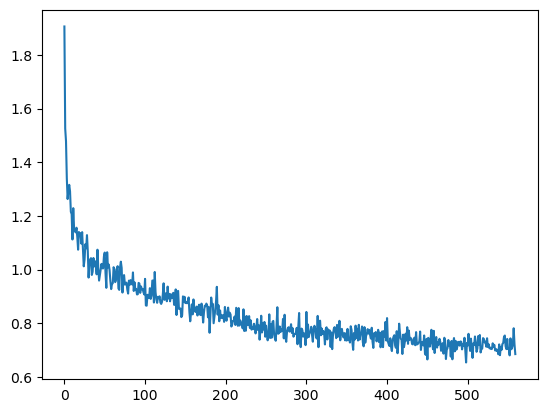

In [10]:
plt.plot(lossArr)

In [11]:
PATH = './models/modelAdamWeightDecayLabelSmoothScheduler.pth'
torch.save(net.state_dict(), PATH)